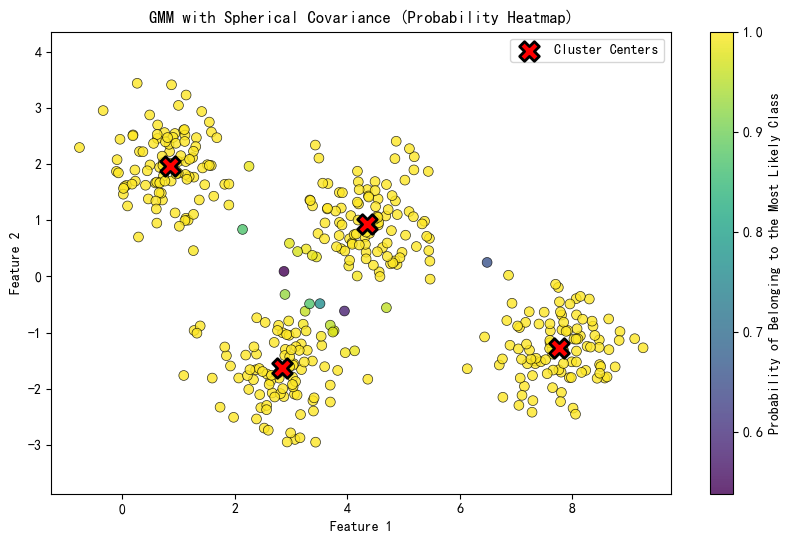

In [3]:
# 球形分布 GMM 概率可视化
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# 生成数据
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=0)
X = X[:, ::-1]  # 交换列以便画图

# 定义绘制概率色温图的函数
def plot_probability_heatmap(gmm, X, title):
    # 计算每个点属于每个类别的概率
    probabilities = gmm.predict_proba(X)
    
    # 获取每个点最可能属于的类别及其概率
    most_likely_class = np.argmax(probabilities, axis=1)
    max_prob = np.max(probabilities, axis=1)
    
    # 绘制散点图，颜色表示概率
    scatter = plt.scatter(X[:, 0], X[:, 1], c=max_prob, cmap='viridis', 
                         s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
    
    # 添加颜色条，标注概率
    cbar = plt.colorbar(scatter)
    cbar.set_label('Probability of Belonging to the Most Likely Class')
    
    # 绘制每个类别的中心
    plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', s=200, marker='X', 
               edgecolors='k', linewidths=2, label='Cluster Centers')
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.axis('equal')

# 训练球形分布 GMM
gmm_spherical = GaussianMixture(n_components=4, covariance_type='spherical', random_state=42)
gmm_spherical.fit(X)

# 绘制概率色温图
plt.figure(figsize=(10, 6))
plot_probability_heatmap(gmm_spherical, X, 'GMM with Spherical Covariance (Probability Heatmap)')
plt.show()

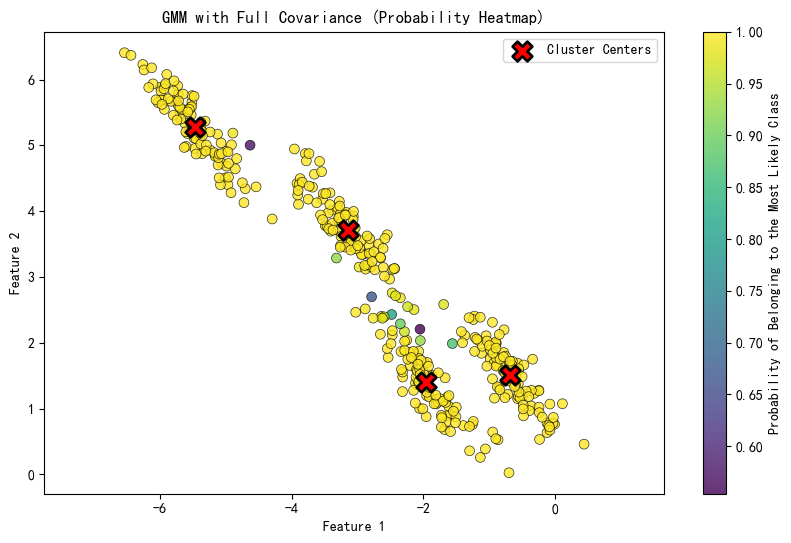

In [5]:
# 椭圆形分布 GMM 概率可视化
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# 生成数据（通过矩阵乘法拉伸数据，使其呈现椭圆形分布）
rng = np.random.RandomState(13)
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=0)
X = X[:, ::-1]  # 交换列以便画图
X_stretched = np.dot(X, rng.randn(2, 2))  # 拉伸数据，使其呈现椭圆形

# 训练椭圆形分布 GMM
gmm_full = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_full.fit(X_stretched)

# 绘制概率色温图（使用与球形分布相同的函数）
plt.figure(figsize=(10, 6))
plot_probability_heatmap(gmm_full, X_stretched, 'GMM with Full Covariance (Probability Heatmap)')
plt.show()

--- 球形分布 GMM 概率可视化 ---


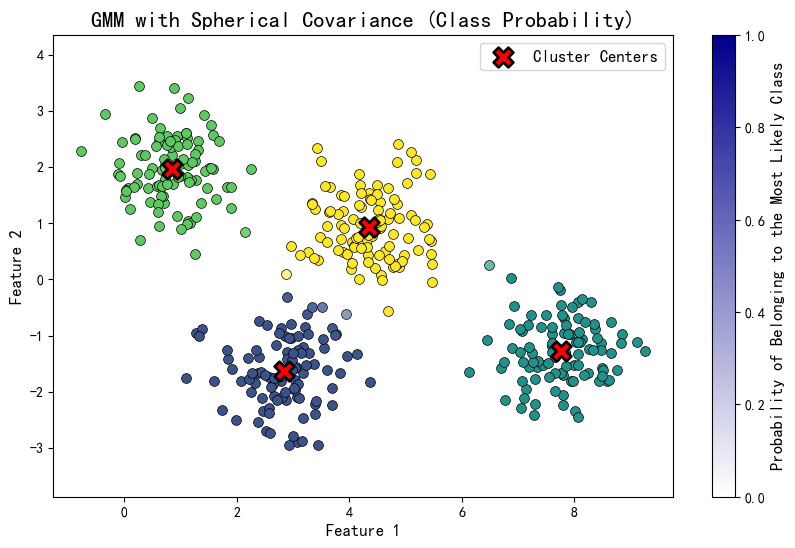


--- 椭圆形分布 GMM 概率可视化 ---


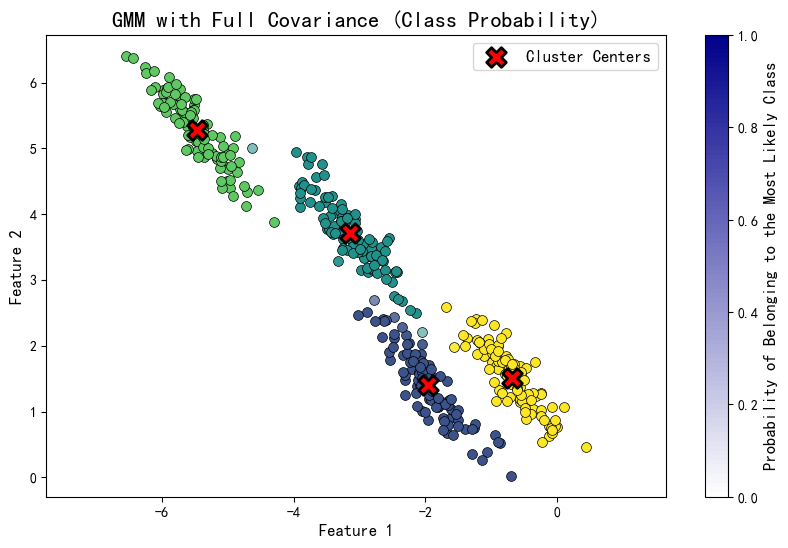

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from matplotlib.colors import LinearSegmentedColormap # 修正导入路径

# 生成原始数据
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=0)
X = X[:, ::-1]

# 生成拉伸后的数据（用于椭圆形分布演示）
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

# 定义绘制概率色温图的函数
def plot_class_probability(gmm, X, title):
    """
    绘制GMM概率图，同一类别使用相同色系，颜色深浅表示属于该类别的概率。
    """
    # 计算每个点属于每个类别的概率
    probabilities = gmm.predict_proba(X)
    
    # 获取每个点最可能属于的类别及其概率
    most_likely_class = np.argmax(probabilities, axis=1)
    max_prob = np.max(probabilities, axis=1)
    
    # 设置图形大小
    plt.figure(figsize=(10, 6))
    
    # 为每个类别定义一个从浅到深的颜色映射
    # 使用 viridis 色系的四个不同区间作为每个类别的主色调
    base_cmap = plt.get_cmap('viridis', 5) # 获取5个离散颜色
    class_colors = base_cmap(np.arange(1, 5)) # 取后4个作为4个类别的主色
    
    # 创建一个颜色映射列表，每个类别对应一个从白到主色的渐变
    cmap_list = [LinearSegmentedColormap.from_list(f'class{i}', ['white', color], N=100) 
                 for i, color in enumerate(class_colors)]

    # 遍历每个数据点进行绘制
    for i in range(len(X)):
        class_idx = most_likely_class[i]
        prob = max_prob[i]
        # 根据概率从对应类别的渐变色板中选择颜色
        color = cmap_list[class_idx](prob)
        plt.scatter(X[i, 0], X[i, 1], color=color, s=50, edgecolors='k', linewidths=0.5)

    # 绘制每个类别的中心
    plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', s=200, marker='X', 
               edgecolors='k', linewidths=2, label='Cluster Centers')
    
    plt.title(title, fontsize=16)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.legend(fontsize=12)
    plt.axis('equal')
    
    # 创建一个通用的颜色条来表示概率
    sm = plt.cm.ScalarMappable(cmap=LinearSegmentedColormap.from_list('prob_cmap', ['white', 'darkblue'], N=100), 
                               norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Probability of Belonging to the Most Likely Class', fontsize=12)
    
    plt.show()

# --- 球形分布 GMM ---
print("--- 球形分布 GMM 概率可视化 ---")
gmm_spherical = GaussianMixture(n_components=4, covariance_type='spherical', random_state=42)
gmm_spherical.fit(X)
plot_class_probability(gmm_spherical, X, 'GMM with Spherical Covariance (Class Probability)')

# --- 椭圆形分布 GMM ---
print("\n--- 椭圆形分布 GMM 概率可视化 ---")
gmm_full = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_full.fit(X_stretched)
plot_class_probability(gmm_full, X_stretched, 'GMM with Full Covariance (Class Probability)')